# CIFAR-10 Neural Network Classification

This project explores image classification on the CIFAR-10 dataset using neural networks.

Two architectures are compared:
- A feedforward neural network (FNN) using flattened image features
- A convolutional neural network (CNN) using the original spatial image structure

The models are implemented with TensorFlow/Keras and evaluated based on their classification performance.

## 1. Data Loading and Exploration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Check dataset shapes
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)
y_test shape: (10000, 1)


### Class Labels

CIFAR-10 contains 10 image classes, represented by integer labels from 0 to 9.

In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display label mapping
for label, class_name in enumerate(class_names):
    print(f"{label}: {class_name}")

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


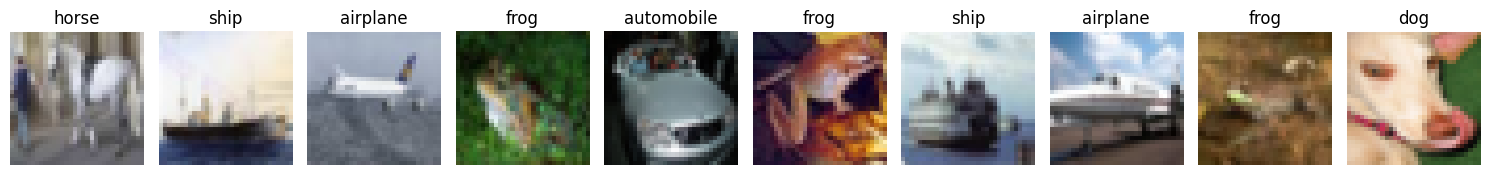

In [3]:
# Randomly select 10 training images
np.random.seed(42)
indices = np.random.choice(len(x_train), 10, replace=False)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preprocessing

Pixel values are normalized to the range `[0, 1]`.

For the FNN model, each 32×32 RGB image is flattened into a 3,072-dimensional feature vector, and the labels are converted to one-hot encoded vectors.

In [4]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images for the FFNN model
x_train_flat = x_train.reshape(x_train.shape[0], 32 * 32 * 3)
x_test_flat = x_test.reshape(x_test.shape[0], 32 * 32 * 3)

# One-hot encode labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("Flattened x_train shape:", x_train_flat.shape)
print("Flattened x_test shape:", x_test_flat.shape)
print("Encoded y_train shape:", y_train_encoded.shape)
print("Encoded y_test shape:", y_test_encoded.shape)

Flattened x_train shape: (50000, 3072)
Flattened x_test shape: (10000, 3072)
Encoded y_train shape: (50000, 10)
Encoded y_test shape: (10000, 10)


## 2. FNN Model Building

A feedforward neural network with five hidden layers is constructed as the baseline model for CIFAR-10 image classification.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# Set random seed for reproducibility
keras.utils.set_random_seed(42)

# Build the feedforward neural network
model = keras.Sequential()
model.add(layers.Input(shape=(3072,)))

# Add five hidden Dense layers
for _ in range(5):
    model.add(layers.Dense(512, activation='relu'))

# Output layer
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,629,130 (10.03 MB)

 Trainable params: 2,629,130 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

## 3. FNN Model Training and Evaluation

The baseline FNN is trained for 20 epochs with a batch size of 128. Model performance is evaluated using classification accuracy on the test set.

In [6]:
# Train the model
history = model.fit(
    x_train_flat,
    y_train_encoded,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate on the held-out test set
test_loss, test_accuracy = model.evaluate(
    x_test_flat,
    y_test_encoded,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2972 - loss: 1.9077 - val_accuracy: 0.3505 - val_loss: 1.7790
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3710 - loss: 1.7402 - val_accuracy: 0.3763 - val_loss: 1.7255
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4035 - loss: 1.6540 - val_accuracy: 0.3995 - val_loss: 1.6776
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4233 - loss: 1.5940 - val_accuracy: 0.4299 - val_loss: 1.5999
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4466 - loss: 1.5365 - val_accuracy: 0.4364 - val_loss: 1.6125
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4624 - loss: 1.4891 - val_accuracy: 0.4377 - val_loss: 1.5964
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4796 - loss: 1.4431 - val_accuracy: 0.4397 - val_loss: 1.5809
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4882 - loss: 1.4154 - val_accu

### Training Curves

Training and validation accuracy and loss are plotted across epochs to examine the learning behavior and potential overfitting of the baseline model.

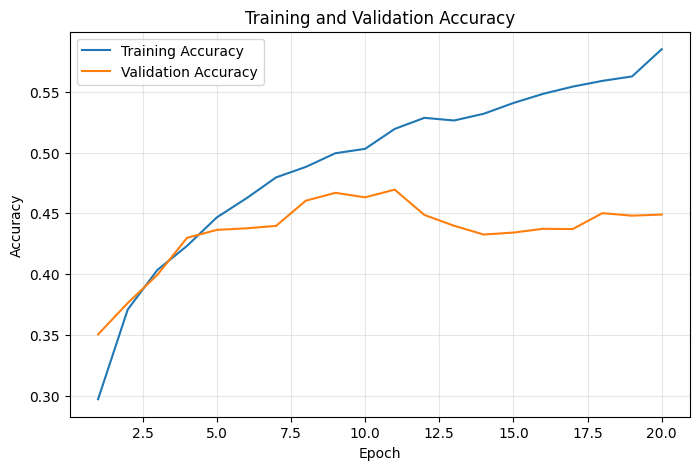

In [7]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

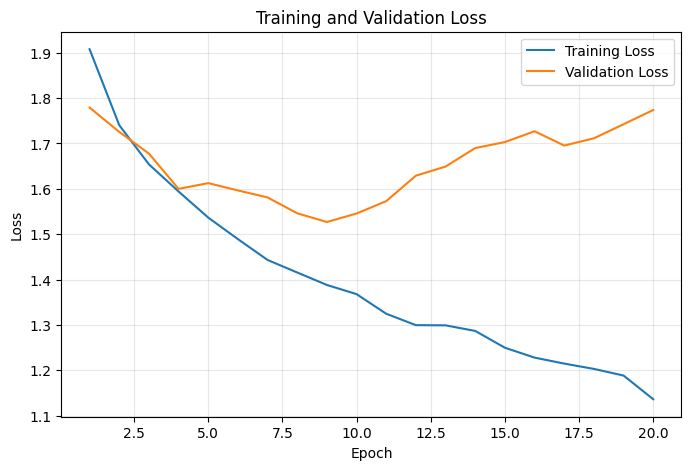

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The training curves show a growing gap between training and validation performance, indicating that the baseline FNN begins to overfit as training progresses.

### Early Stopping

Based on the observed overfitting, early stopping is introduced to stop training when validation loss no longer improves and restore the best model weights.

In [9]:
keras.utils.set_random_seed(42)

model = keras.Sequential()
model.add(layers.Input(shape=(3072,)))

for _ in range(5):
    model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

fnn_es_history = model.fit(
    x_train_flat,
    y_train_encoded,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[fnn_early_stopping],
    verbose=1
)

fnn_es_loss, fnn_es_accuracy = model.evaluate(
    x_test_flat,
    y_test_encoded,
    verbose=0
)

print(f"Early-stopped test loss: {fnn_es_loss:.4f}")
print(f"Early-stopped test accuracy: {fnn_es_accuracy:.4f}")

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2972 - loss: 1.9077 - val_accuracy: 0.3505 - val_loss: 1.7790
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3710 - loss: 1.7402 - val_accuracy: 0.3763 - val_loss: 1.7255
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4035 - loss: 1.6540 - val_accuracy: 0.3995 - val_loss: 1.6776
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4233 - loss: 1.5940 - val_accuracy: 0.4299 - val_loss: 1.5999
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4466 - loss: 1.5365 - val_accuracy: 0.4364 - val_loss: 1.6125
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4624 - loss: 1.4891 - val_accuracy: 0.4377 - val_loss: 1.5964
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4796 - loss: 1.4431 - val_accuracy: 0.4397 - val_loss: 1.5809
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4882 - loss: 1.4154 - val_accu

## 4. CNN Data Preprocessing and Model Building

Unlike the FNN, the CNN uses the normalized images in their original 32×32×3 spatial format rather than flattened feature vectors. The same one-hot encoded class labels are used for training and evaluation.

The CNN consists of three convolutional blocks with increasing filter sizes, followed by a fully connected layer for 10-class classification.

In [10]:
# Verify input shapes for the CNN
print("CNN training image shape:", x_train.shape)
print("CNN test image shape:", x_test.shape)
print("Training label shape:", y_train_encoded.shape)
print("Test label shape:", y_test_encoded.shape)

CNN training image shape: (50000, 32, 32, 3)
CNN test image shape: (10000, 32, 32, 3)
Training label shape: (50000, 10)
Test label shape: (10000, 10)


In [11]:
# Set random seed for reproducibility
keras.utils.set_random_seed(42)

# Build the CNN
cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Convolutional block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5. CNN Model Training and Evaluation

The CNN is trained using the Adam optimizer and categorical cross-entropy loss. A portion of the training data is reserved for validation, while the test set is used only for final evaluation.

In [12]:
# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
cnn_history = cnn_model.fit(
    x_train,
    y_train_encoded,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on the held-out test set
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print(f"Test loss: {cnn_test_loss:.4f}")
print(f"Test accuracy: {cnn_test_accuracy:.4f}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4680 - loss: 1.4663 - val_accuracy: 0.5881 - val_loss: 1.1594
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6352 - loss: 1.0433 - val_accuracy: 0.6552 - val_loss: 0.9757
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6939 - loss: 0.8785 - val_accuracy: 0.6872 - val_loss: 0.9085
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7293 - loss: 0.7721 - val_accuracy: 0.6990 - val_loss: 0.8894
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7604 - loss: 0.6848 - val_accuracy: 0.7084 - val_loss: 0.8686
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7921 - loss: 0.6033 - val_accuracy: 0.7276 - val_loss: 0.8288
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8163 - loss: 0.5328 - val_accuracy: 0.7164 - val_loss: 0.8934
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8393 - loss: 0.4674 - val_acc

### Training Curves

Training and validation accuracy and loss are monitored across epochs to examine convergence and generalization.

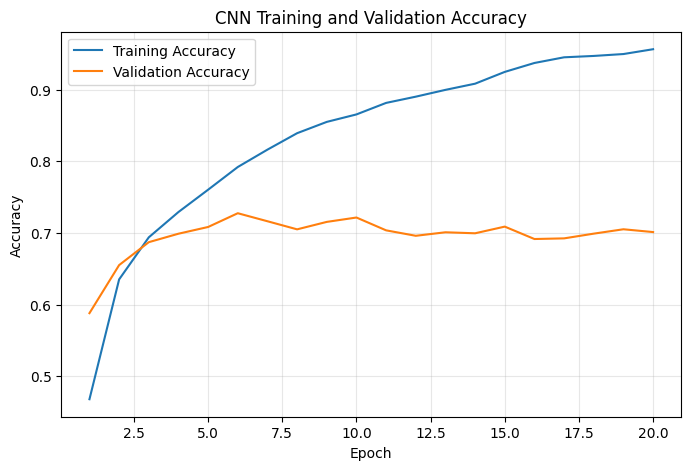

In [13]:
cnn_epochs = range(1, len(cnn_history.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(cnn_epochs, cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_epochs, cnn_history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

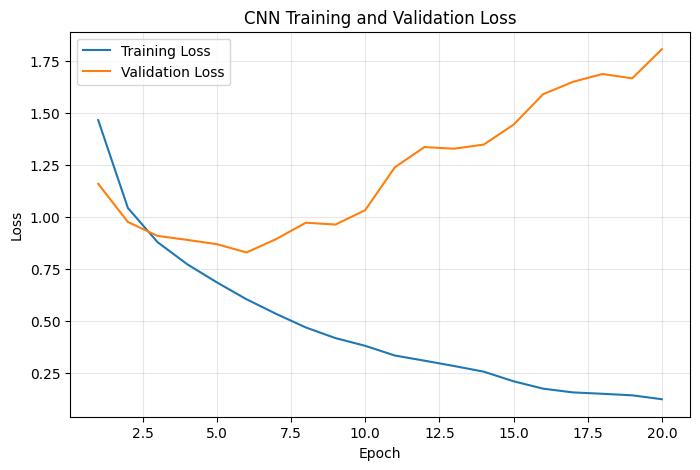

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(cnn_epochs, cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_epochs, cnn_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Although the CNN substantially improves classification accuracy over the FNN, the training curves still show increasing divergence between training and validation performance, suggesting overfitting in later epochs.

In [15]:
keras.utils.set_random_seed(42)

cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_history = cnn_model.fit(
    x_train,
    y_train_encoded,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[cnn_early_stopping],
    verbose=1
)

cnn_es_loss, cnn_es_accuracy = cnn_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print(f"Early-stopped test loss: {cnn_es_loss:.4f}")
print(f"Early-stopped test accuracy: {cnn_es_accuracy:.4f}")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4680 - loss: 1.4663 - val_accuracy: 0.5881 - val_loss: 1.1594
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6352 - loss: 1.0433 - val_accuracy: 0.6552 - val_loss: 0.9757
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6939 - loss: 0.8785 - val_accuracy: 0.6872 - val_loss: 0.9085
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7293 - loss: 0.7721 - val_accuracy: 0.6990 - val_loss: 0.8894
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7604 - loss: 0.6848 - val_accuracy: 0.7084 - val_loss: 0.8686
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7921 - loss: 0.6033 - val_accuracy: 0.7276 - val_loss: 0.8288
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8163 - loss: 0.5328 - val_accuracy: 0.7164 - val_loss: 0.8934
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8393 - loss: 0.4674 - val_acc

## 6. Model Comparison and Conclusions

This project compared a feedforward neural network (FNN) and a convolutional neural network (CNN) for CIFAR-10 image classification. Both models were first trained for a fixed 20 epochs to examine their learning behavior. The training and validation curves showed that both models began to overfit, with the effect being particularly clear for the CNN.

To address this issue, Early Stopping was introduced based on validation loss, with the best-performing model weights restored before final evaluation on the held-out test set.

### Performance Comparison

| Model | Training Strategy | Test Accuracy | Test Loss |
|---|---|---:|---:|
| FNN | 20 Epochs | 44.77% | 1.7663 |
| FNN | Early Stopping | 47.17% | 1.5150 |
| CNN | 20 Epochs | 70.26% | 1.7846 |
| CNN | Early Stopping | **72.37%** | **0.8420** |

### Key Findings

**1. CNN substantially outperformed the FNN.**

The early-stopped CNN achieved **72.37% test accuracy**, compared with **47.17%** for the early-stopped FNN, an improvement of approximately **25.2 percentage points**.

The FNN operates on flattened 3,072-dimensional image vectors, which removes the original spatial structure of the images. In contrast, the CNN applies convolutional filters directly to the 32×32 RGB images, allowing it to learn local spatial patterns and hierarchical visual features. This makes the CNN much better suited for image classification.

**2. The baseline training curves revealed overfitting.**

For both architectures, training performance continued to improve while validation performance eventually plateaued or deteriorated. This behavior was especially pronounced for the CNN, where training accuracy continued to increase while validation accuracy remained relatively stable and validation loss increased substantially.

This growing gap between training and validation performance indicates that additional training was primarily improving the models' fit to the training data rather than their ability to generalize to unseen images.

**3. Early Stopping improved generalization.**

Early Stopping was introduced after observing this overfitting behavior. Instead of training for a predetermined number of epochs, training was stopped when validation loss no longer improved, and the weights from the best validation epoch were restored.

For the FNN, test accuracy improved from **44.77% to 47.17%**.

For the CNN, test accuracy improved from **70.26% to 72.37%**, while test loss decreased substantially from **1.7846 to 0.8420**.

### Conclusion

The experiments demonstrate the importance of both model architecture and training strategy in image classification. Replacing the fully connected architecture with a convolutional architecture produced the largest performance improvement, demonstrating the advantage of preserving and learning spatial image features.

The learning curves also showed that simply continuing training does not necessarily improve generalization. By identifying overfitting through validation performance and applying Early Stopping, both models achieved better performance on unseen test data.

Overall, the CNN with Early Stopping achieved the best result, reaching **72.37% test accuracy on CIFAR-10**.